# **MÓDULO 39 - Exercicio - Aplicando SVM**

Nessa atividade vocês usarão uma base já connhecida, a base de propensão a compra de carros. A mesma que também usamos na tarefa de XGboost!


In [31]:
from sklearn.svm import SVC
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


In [2]:
#SEU CÓDIGO AQUI

In [3]:
# Importar Data Frame
base = pd.read_csv('CARRO_CLIENTES.csv')

In [4]:
base

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0
...,...,...,...,...,...
995,863,Male,38,59000,0
996,800,Female,47,23500,0
997,407,Female,28,138500,1
998,299,Female,48,134000,1


In [5]:
# Verificar tipo de dados
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


In [6]:
# Verificar Nulos
base.isnull().sum()

User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64

In [7]:
# Remover coluna 'User ID'
base = base.drop(columns=['User ID'])

In [8]:
base.describe()

,Age,AnnualSalary,Purchased
count,1000.000000,1000.000000,1000.000000
mean,40.106000,72689.000000,0.402000
std,10.707073,34488.341867,0.490547
min,18.000000,15000.000000,0.000000
25%,32.000000,46375.000000,0.000000
50%,40.000000,72000.000000,0.000000
75%,48.000000,90000.000000,1.000000
max,63.000000,152500.000000,1.000000


Todos os dados estão dentro do esperado para cada coluna

# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

In [9]:
#SEU CÓDIGO AQUI

In [10]:
# Aplicar Label Encoder
le = LabelEncoder()

base['Gender_encoded'] = le.fit_transform(base['Gender'])

In [11]:
# Remover coluna categórica
base = base.drop(columns=['Gender'])

In [12]:
print(base[['Gender_encoded']].head())

   Gender_encoded
0               1
1               1
2               1
3               1
4               1


# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

In [13]:
#SEU CÓDIGO AQUI

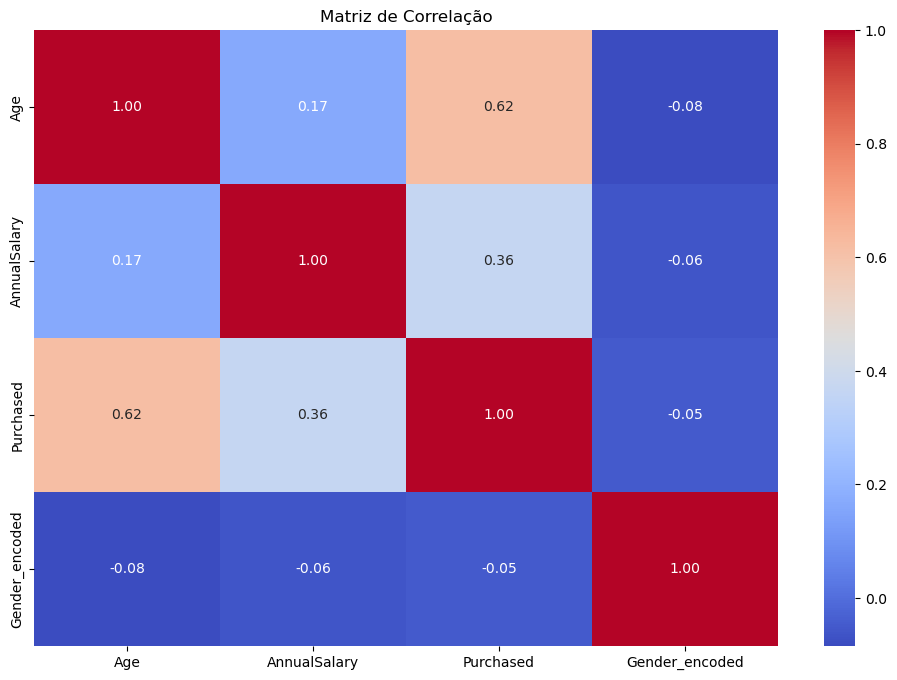

In [14]:
# Criar e visualizar Matriz de correlação
corr_matrix = base.corr()


plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

- Age vs Purchased (0.62): há uma correlação positiva forte, indicando que a idade influencia significativamente a intenção de compra. Clientes mais velhos parecem ter maior probabilidade de comprar.
- AnnualSalary vs Purchased (0.36): correlação moderada, sugerindo que renda mais alta aumenta a chance de compra, mas não é o fator principal.
- Age vs AnnualSalary (0.17): relação fraca, mostrando que idade não explica bem a variação de salário na base.
- Gender_encoded apresenta correlações muito baixas com todas as variáveis (-0.05 a -0.08), indicando que gênero não tem impacto significativo sobre idade, salário ou intenção de compra neste conjunto de dados.

Portanto idade é o fator mais associado à compra online, seguido por renda, enquanto gênero praticamente não influencia. Isso sugere que campanhas podem ser mais eficazes se segmentadas por faixa etária e poder aquisitivo.

# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [15]:
#SEU CÓDIGO AQUI

In [16]:
# Definir X e y
X = base.drop(columns=['Purchased'])
y = base['Purchased']

# Separando em treino e teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [17]:
# Verificar os tamanhos
print("Tamanho treino:", X_train.shape, y_train.shape)
print("Tamanho teste:", X_test.shape, y_test.shape)

Tamanho treino: (700, 3) (700,)
Tamanho teste: (300, 3) (300,)


**Todos passos até aqui vocês realizaram na tarefa anterior também!**

# 5. Treino o modelo SVM com sua base de treino.
Esse modelo deve ser treinado usando o kernel linear.

In [18]:
#SEU CÓDIGO AQUI

In [19]:
svm_model = SVC(kernel =  'linear', random_state = 1, C = 1.0)
svm_model.fit(X_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


# 6. Realize as previsões para a base de teste e traga a avaliação.

In [20]:
#SEU CÓDIGO AQUI

In [21]:
y_pred = svm_model.predict(X_train)
y_pred

array([0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,

In [22]:
report = classification_report(y_train, y_pred)
print("Relatório de Classificação:\n", report)

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87       426
           1       0.80      0.78      0.79       274

    accuracy                           0.84       700
   macro avg       0.83      0.83      0.83       700
weighted avg       0.84      0.84      0.84       700



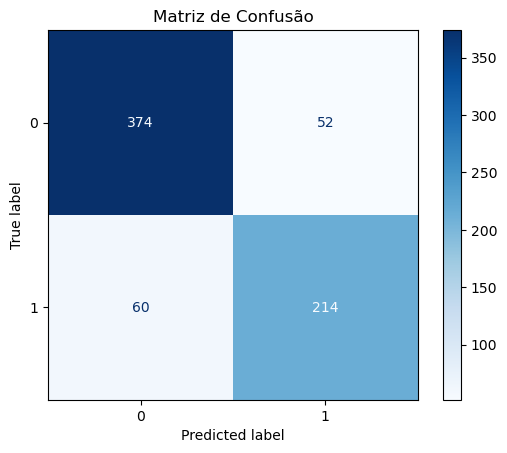

In [34]:
# Gerando a matriz de confusão
cm = confusion_matrix(y_train, y_pred)

# Exibindo com ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão")
plt.show()

In [24]:
accuracy = accuracy_score(y_train, y_pred)
print("Acurácia:", accuracy)

Acurácia: 0.84


# 7. Treine um novo modelo SVM com sua base de treino + realize as previsões e avalições.
Esse modelo dedve ser treinado usando o kernel poly.

In [ ]:
#SEU CÓDIGO AQUI

In [25]:
svm_model_poly = SVC(kernel =  'poly', random_state = 1, C = 1.0)
svm_model_poly.fit(X_train,y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [26]:
y_pred_poly = svm_model_poly.predict(X_train)
y_pred_poly

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [27]:
report = classification_report(y_train, y_pred_poly)
print("Relatório de Classificação:\n", report)

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.72      0.95      0.82       426
           1       0.84      0.41      0.55       274

    accuracy                           0.74       700
   macro avg       0.78      0.68      0.69       700
weighted avg       0.77      0.74      0.71       700



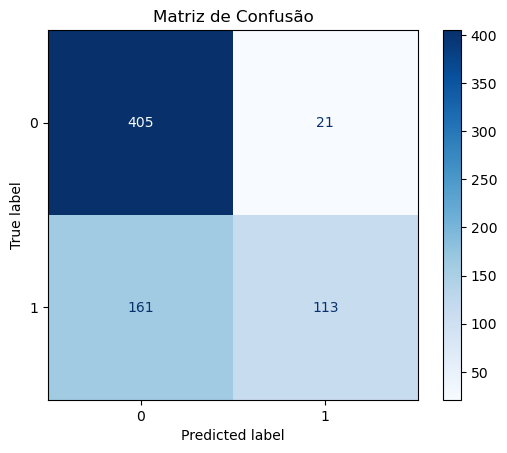

In [33]:
# Gerando a matriz de confusão
cm_poly = confusion_matrix(y_train, y_pred_poly)

# Exibindo com ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm_poly, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão")
plt.show()

In [28]:
accuracy = accuracy_score(y_train, y_pred_poly)
print("Acurácia:", accuracy)

Acurácia: 0.74


# 8. Qual modelo se saiu melhor? O SVM com kernel linear ou poly? Compare também com o XGboost, da atividade anterior, você obteve melhores previsões com qual dos modelos?

Comparando os resultados:

 - SVM Linear: obteve acurácia de 84%, com desempenho equilibrado entre as classes. A classe 0 teve recall de 0.88 e a classe 1 de 0.78, mostrando boa capacidade de generalização.
 - SVM Poly: caiu para 74% de acurácia. Apesar de ter recall muito alto para a classe 0 (0.95), teve desempenho fraco para a classe 1 (recall de 0.41), o que indica desequilíbrio e dificuldade em classificar corretamente os compradores.
 - XGBoost: alcançou 90% de acurácia, com precisão e recall próximos de 0.90 para ambas as classes, mostrando melhor equilíbrio e maior confiabilidade.

Portanto o SVM Linear foi superior ao SVM Poly, pois manteve resultados mais consistentes. O XGBoost se saiu melhor que ambos, apresentando maior acurácia e métricas mais equilibradas sendo protanto o melhor modelo para esse conjunto de dados.